# Pytorch datasets and dataloaders.
This notebook is shamelessly adapted from the great offical torch tutorials: feel free to go there for more details
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html, and https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

### from scratch

In [2]:
data = pd.read_csv('data/LLC_sc_CCSB.txt', sep=',', index_col=0)
t = data['Time'].values
size = data['Vol'].values

norm_t = t - np.mean(t)
norm_t /= np.std(t)

norm_size = size - np.mean(size)
norm_size /= np.std(norm_size)


In [3]:
class CustomTorchDataset(Dataset):
    def __init__(self, xs, ys):
        self.xs = xs
        self.ys = ys
    
    def __len__(self):
        return len(self.ys)
    
    def __getitem__(self, idx):
        x = torch.as_tensor(self.xs[idx], dtype=torch.float32)
        x = x.unsqueeze(0)  # makes it (1,)
        y = torch.as_tensor(self.ys[idx], dtype=torch.float32)
        y = y.unsqueeze(0)  # makes it (1,)
        return x, y 


In [4]:
dataset = CustomTorchDataset(xs=norm_t, ys=norm_size)
len(dataset)

173

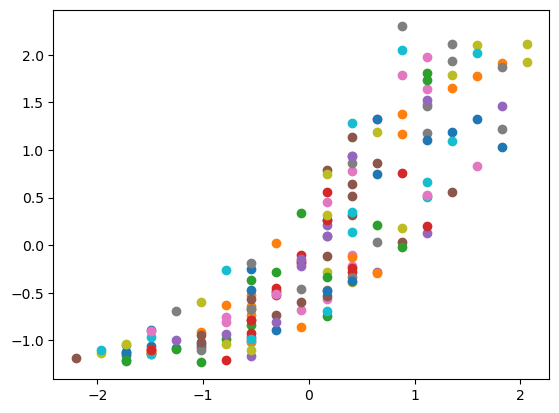

In [5]:
for i, (x, y) in enumerate(dataset):
    plt.scatter(x, y)

In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


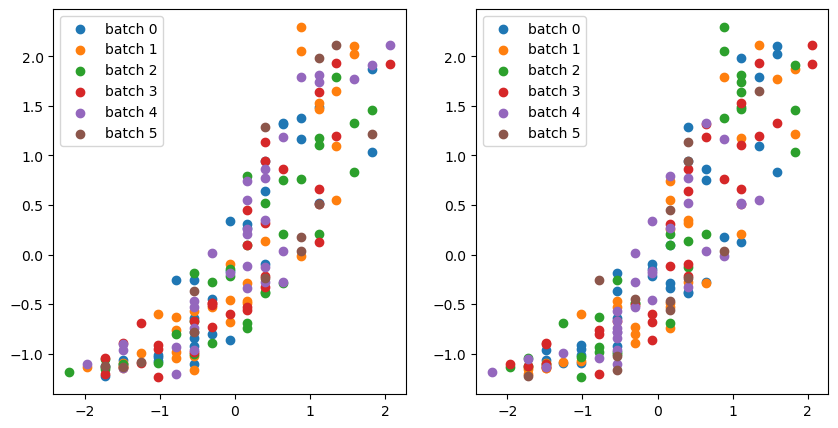

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for epoch in range(2):
    for batch, (x, y) in enumerate(dataloader):
        ax[epoch].scatter(x, y, label=f'batch {batch}')
    ax[epoch].legend()

You can see that the shuffle and the batch is done autmatically, at every epoch

In [8]:

class SimpleNonlinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 4),   # First hidden layer
            torch.nn.ReLU(),
            torch.nn.Linear(4, 1)    # Output layer
        )
    
    def forward(self, x):
        return self.model(x)
    
model_simple = SimpleNonlinearNN()
total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Total parameters: {total_params}")

criterion = torch.nn.MSELoss(size_average = False)
optimizer = torch.optim.SGD(model_simple.parameters(), lr = 0.001)

Total parameters: 13


/opt/homebrew/Caskroom/miniconda/base/envs/DL_intro_VHIO/lib/python3.13/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [9]:
## We can simplify our trainng function as the batching anf the suffling is done already:
def train_model(model, optimizer):
    losses_steps = []
    losses_epochs = []

    for epoch in range(50):
        loss_epoch = 0

        '''no need for this anymore'''
        #shuffle the trainig data each epoch for better stochasticity
        # indices = torch.randperm(n_train_samples)
        # x_shuffled = x_train[indices]
        # y_shuffled = y_train[indices]

        # loop through the dataset per batch
        # for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
        for b, (x_batch, y_batch) in enumerate(dataloader):
            '''no need for this anymore'''
            # take only the current batch
            # end_idx = start_idx + batch_size
            # x_batch = x_shuffled[start_idx:end_idx]
            # y_batch = y_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
            
        # Compute the mean loss on the epoch
        losses_epochs.append(loss_epoch / (b+1))
    return losses_epochs, losses_steps


<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_23177/1758971230.py:12: SyntaxWarning: invalid escape sequence '\h'
  [axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]


Text(0.5, 1.0, 'Loss per epochs')

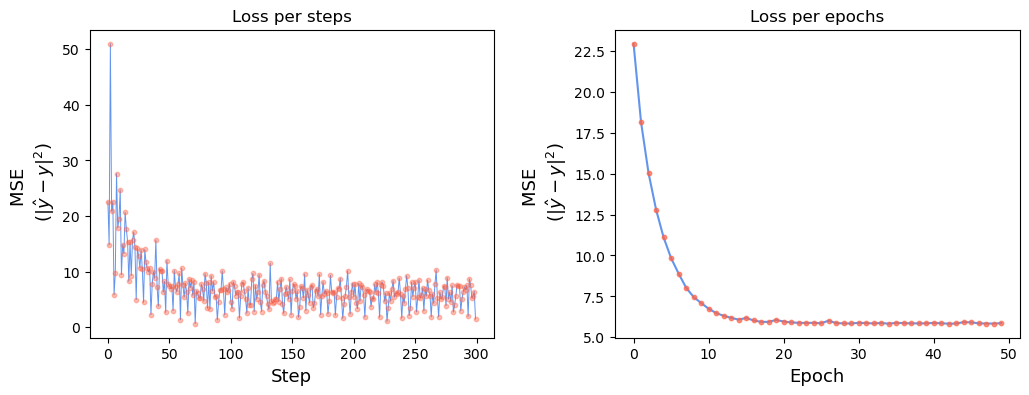

In [10]:
losses_epochs, losses_steps = train_model(model_simple, optimizer)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5)
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='cornflowerblue', lw=.7)


ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='tomato', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='cornflowerblue')


[axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')

Note that we should first shuffle our data, make a train and testing sets, and then cerate a train dataloader and a test data loader.

# Example with the brain tumour dataset

In [14]:
import glob
import cv2

In [15]:
class CustomTorchDataset(Dataset):
    def __init__(self, image_path, train_or_test):
        imgs_glioma = []
        for img_name in glob.glob(f'{image_path}/{train_or_test}/glioma/*.jpg'):
            im = cv2.imread(img_name)
            
            if len(np.shape(im)) == 3:
                im = np.array(im)[..., -1]
            im = cv2.resize(im, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)
            imgs_glioma.append(im)

        ## Healthy images
        imgs_no_tumour = []
        for img_name in glob.glob(f'{image_path}/{train_or_test}/notumor/*.jpg'):
            im = cv2.imread(img_name)
            
            if len(np.shape(im)) == 3:
                im = np.array(im)[..., -1]
            im = cv2.resize(im, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)
            imgs_no_tumour.append(im)

        y = np.zeros(len(imgs_glioma) + len(imgs_no_tumour))
        y[:len(imgs_glioma)] = 1
        x = np.concatenate((imgs_glioma, imgs_no_tumour))

        self.xs = x
        self.ys = y
    
    def __len__(self):
        return len(self.ys)
    
    def __getitem__(self, idx):
        x = torch.as_tensor(self.xs[idx], dtype=torch.float32)
        # x = x.unsqueeze(0)  # makes it (1,)
        y = torch.as_tensor(self.ys[idx], dtype=torch.float32)
        # y = y.unsqueeze(0)  # makes it (1,)
        return x, y 


In [22]:
dataset = CustomTorchDataset('./data/brain_tumours/', 'training')
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)



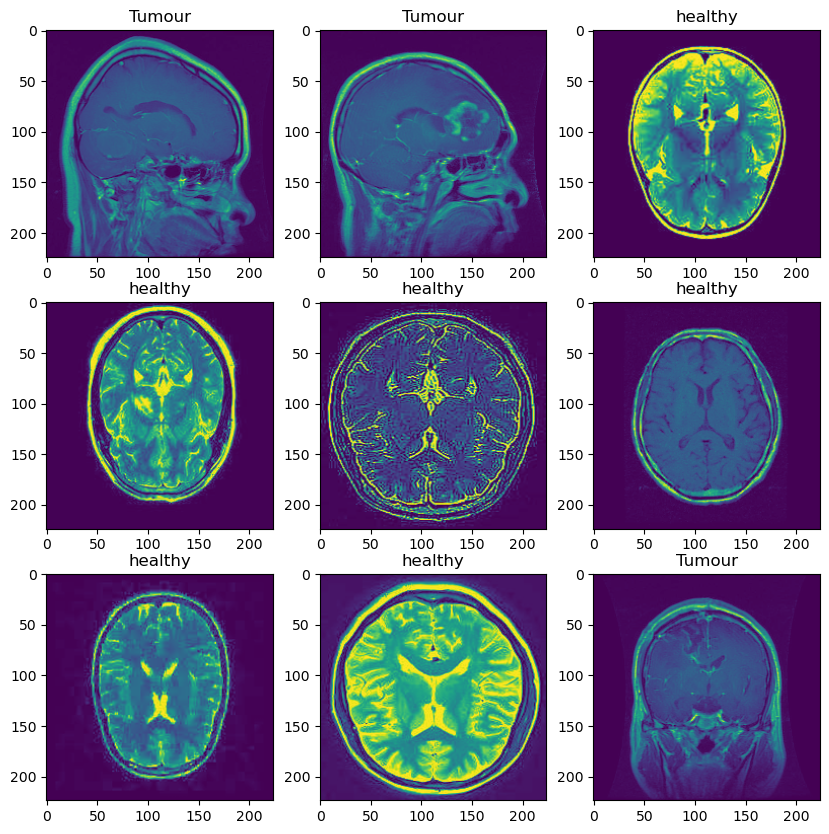

In [24]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
ax = ax.flatten()
for i, (x, y) in enumerate(dataloader):
    if i >= 1:
        break
    for img in range(9):
        ax[img].imshow(x[img])
        if y[img] == 0:
            title = 'healthy'
        else:
            title = 'Tumour'
        ax[img].set_title(title)